## Лабораторная работа №1: Визуализация данных
**Выполнил:** Мещеряков Сергей Евгеньевич  
**Группа:** 6401-01.03.02D

## 1. Загрузка данных и первичный анализ

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from ipywidgets import interact

%matplotlib inline

In [2]:
data = pd.read_csv("game_of_thrones.csv", index_col='S.No')
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


### Описание датасета

Датасет содержит информацию о персонажах вселенной «Игры престолов».

**Целевой признак:** `isAlive` – жив ли персонаж на момент событий (1 – жив, 0 – мёртв).

| Признак | Описание | Тип / Единицы |
|---------|----------|----------------|
| name | Имя персонажа | категориальный |
| title | Титул (лорд, рыцарь и т.д.) | категориальный |
| male | Пол (1 – мужской, 0 – женский) | бинарный |
| culture | Культурная принадлежность | категориальный |
| dateOfBirth | Дата рождения (в летоисчислении AC) | числовой (годы) |
| mother | Имя матери | категориальный |
| father | Имя отца | категориальный |
| heir | Имя наследника | категориальный |
| house | Дом, к которому принадлежит персонаж | категориальный |
| spouse | Имя супруга/супруги | категориальный |
| book1/2/3/4/5 | Появление в книге (1 – есть, 0 – нет) | бинарный |
| isAliveMother | Жива ли мать (1 – да, 0 – нет, NaN – нет данных) | бинарный |
| isAliveFather | Жив ли отец | бинарный |
| isAliveHeir | Жив ли наследник | бинарный |
| isAliveSpouse | Жив ли супруг | бинарный |
| isMarried | Состоит ли в браке | бинарный |
| isNoble | Является ли знатным | бинарный |
| age | Возраст (в годах, 305 AC) | числовой (годы) |
| numDeadRelations | Количество умерших родственников | целый |
| popularity | Рейтинг популярности (число ссылок в вики) | числовой |
| isAlive | Жив ли персонаж (целевая переменная) | бинарный |

## 2. Визуализация с помощью Matplotlib

### 2.1 Несколько графиков разного вида

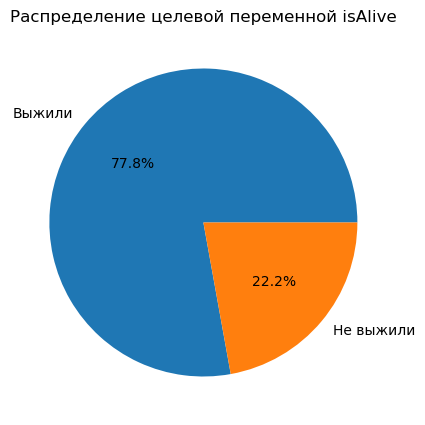

In [3]:
plt.figure(figsize=(7,5))
plt.pie(data['isAlive'].value_counts(), autopct='%1.1f%%', labels=['Выжили','Не выжили'])
plt.title('Распределение целевой переменной isAlive')
plt.show()

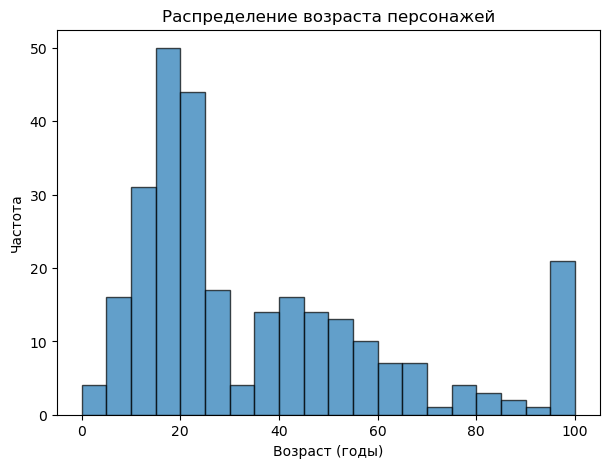

In [4]:
plt.figure(figsize=(7,5))
plt.hist(data['age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Возраст (годы)')
plt.ylabel('Частота')
plt.title('Распределение возраста персонажей')
plt.show()

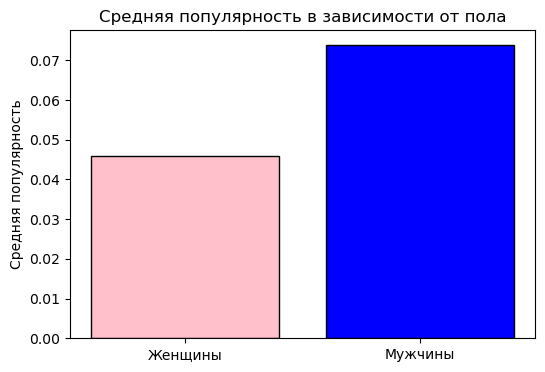

In [5]:
popularity_by_gender = data.groupby('male')['popularity'].mean()
plt.figure(figsize=(6,4))
plt.bar(['Женщины', 'Мужчины'], popularity_by_gender.values, color=['pink', 'blue'], edgecolor='black')
plt.ylabel('Средняя популярность')
plt.title('Средняя популярность в зависимости от пола')
plt.show()

### 2.2 Суб-графики (subplot)

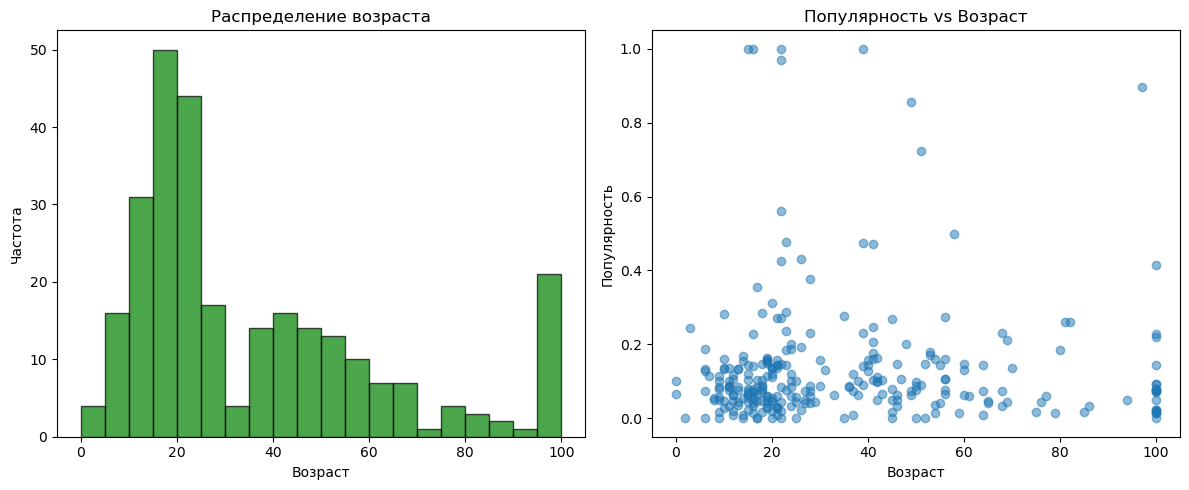

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Первый subplot: гистограмма возраста
axes[0].hist(data['age'].dropna(), bins=20, edgecolor='black', color='green', alpha=0.7)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение возраста')

# Второй subplot: scatter популярности от возраста (с удалением пропусков)
age_pop = data[['age','popularity']].dropna()
axes[1].scatter(age_pop['age'], age_pop['popularity'], alpha=0.5)
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Популярность')
axes[1].set_title('Популярность vs Возраст')

plt.tight_layout()
plt.show()

### 2.3 Интерактивный график со слайдером (matplotlib + ipywidgets)
Построим гистограмму возраста с изменяемым числом бинов.

In [7]:
def plot_age_hist(bins):
    plt.figure(figsize=(7,5))
    plt.hist(data['age'].dropna(), bins=bins, edgecolor='black', alpha=0.7)
    plt.xlabel('Возраст')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма возраста (бинов = {bins})')
    plt.show()

interact(plot_age_hist, bins=widgets.IntSlider(min=5, max=50, step=1, value=20));

interactive(children=(IntSlider(value=20, description='bins', max=50, min=5), Output()), _dom_classes=('widget…

## 3. Визуализация с помощью Pandas

### 3.1 Графики через методы DataFrame и Series

#### Boxplot (с параметром `by`) – через DataFrame

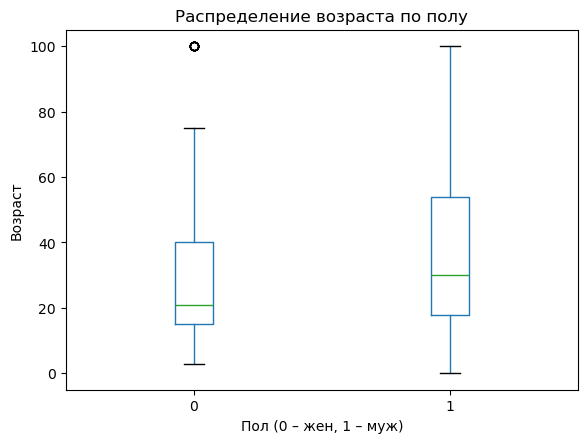

In [8]:
data.boxplot(column='age', by='male', grid=False)
plt.title('Распределение возраста по полу')
plt.suptitle('')
plt.xlabel('Пол (0 – жен, 1 – муж)')
plt.ylabel('Возраст')
plt.show()

#### Два других графика (один через Series, другой через DataFrame)

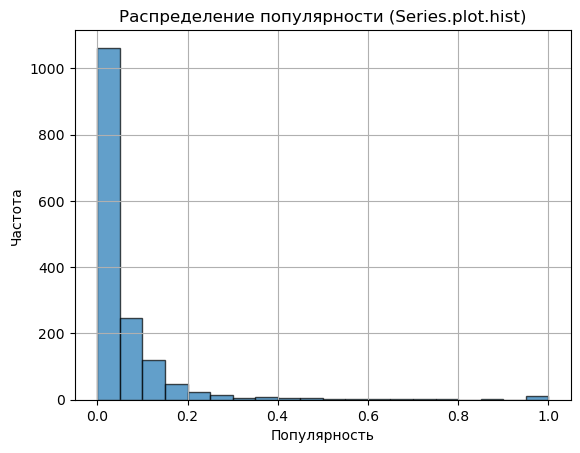

In [9]:
# Через Series
data['popularity'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Популярность')
plt.ylabel('Частота')
plt.title('Распределение популярности (Series.plot.hist)')
plt.show()

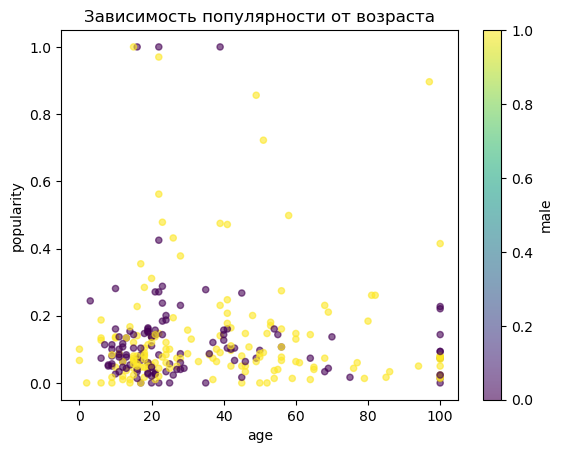

In [10]:
data.plot.scatter(x='age', y='popularity', c='male', colormap='viridis', alpha=0.6)
plt.title('Зависимость популярности от возраста')
plt.show()

## 4. Визуализация с помощью Seaborn

### 4.1 Pairplot для набора числовых признаков

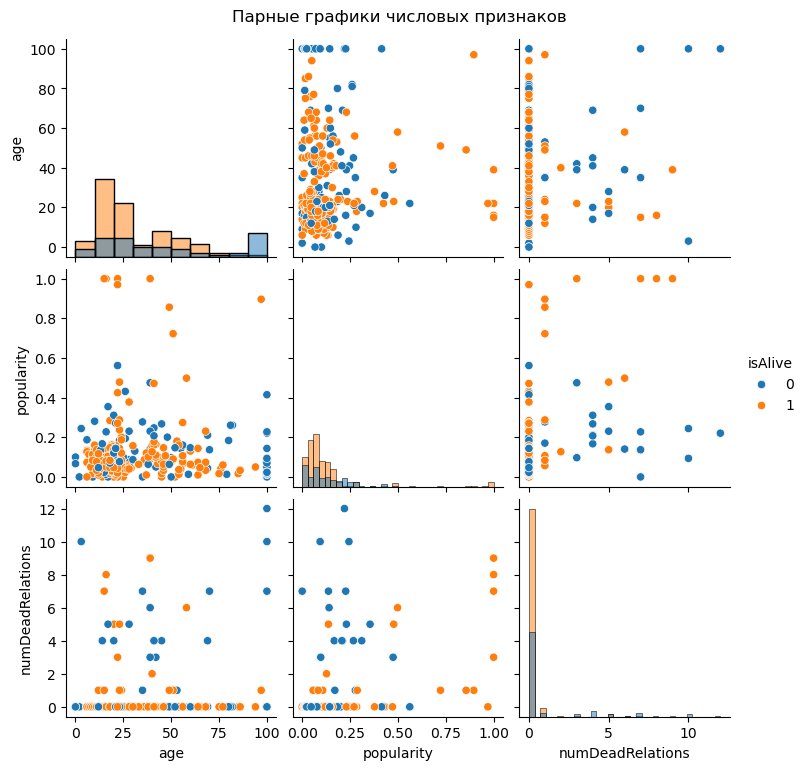

In [11]:
numeric_cols = ['age', 'popularity', 'numDeadRelations', 'isAlive']
sns.pairplot(data[numeric_cols].dropna(), hue='isAlive', diag_kind='hist')
plt.suptitle('Парные графики числовых признаков', y=1.02)
plt.show()

### 4.2 Jointplot для двух признаков

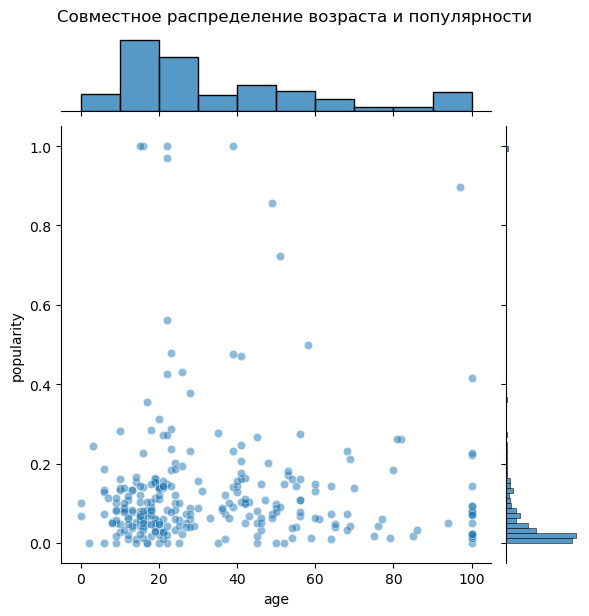

In [12]:
sns.jointplot(data=data, x='age', y='popularity', kind='scatter', alpha=0.5)
plt.suptitle('Совместное распределение возраста и популярности', y=1.02)
plt.show()

### 4.3 Boxplot / Violinplot числового признака в разрезе категориального
Используем `culture` – возьмём несколько наиболее часто встречающихся культур.

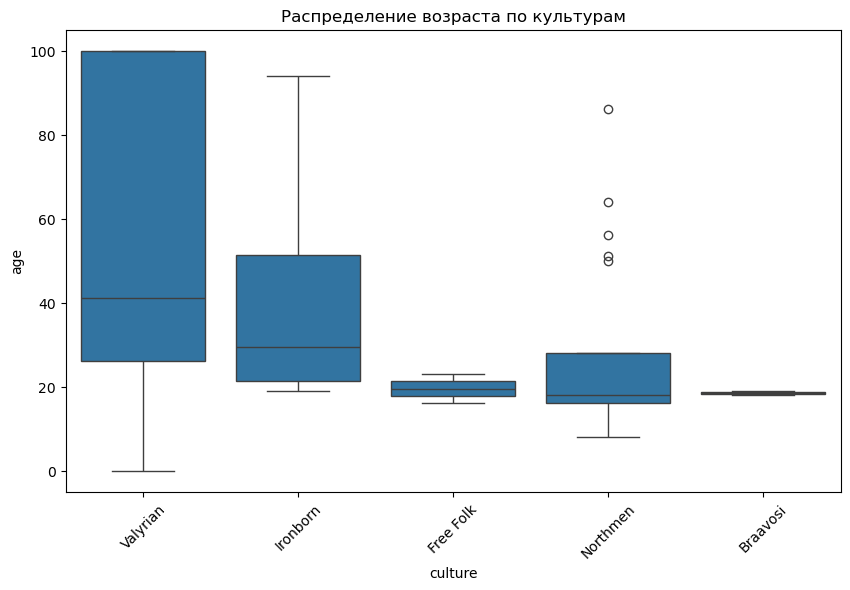

In [13]:
top_cultures = data['culture'].value_counts()
top_cultures = top_cultures[top_cultures > 20].index.tolist()
data_culture = data[data['culture'].isin(top_cultures)]

plt.figure(figsize=(10,6))
sns.boxplot(data=data_culture, x='culture', y='age')
plt.xticks(rotation=45)
plt.title('Распределение возраста по культурам')
plt.show()

### 4.4 Heatmap корреляции числовых признаков

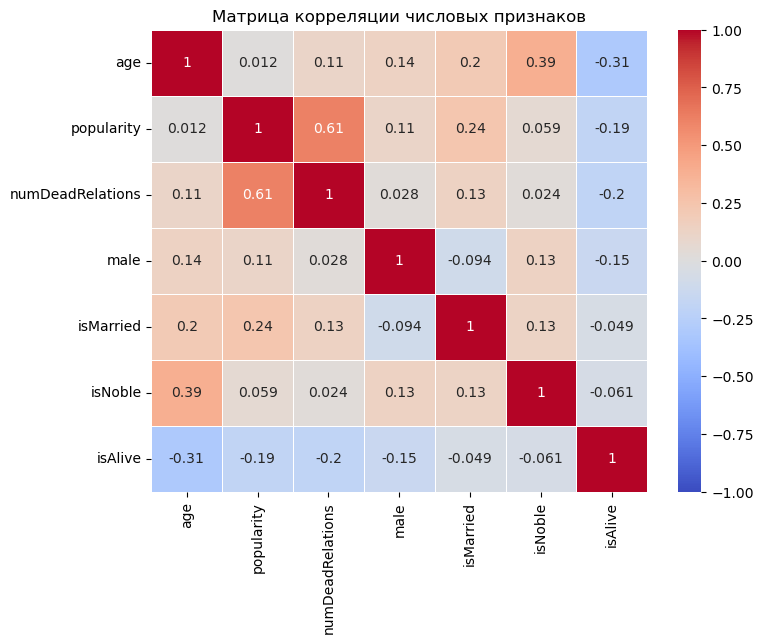

In [14]:
all_numeric = data.select_dtypes(include=[np.number]).columns.tolist()
core_numeric = ['age','popularity','numDeadRelations','male','isMarried','isNoble','isAlive']
corr = data[core_numeric].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

## 5. Проверка на нормальность (scipy.stats)

### QQ-график и гистограмма для возраста

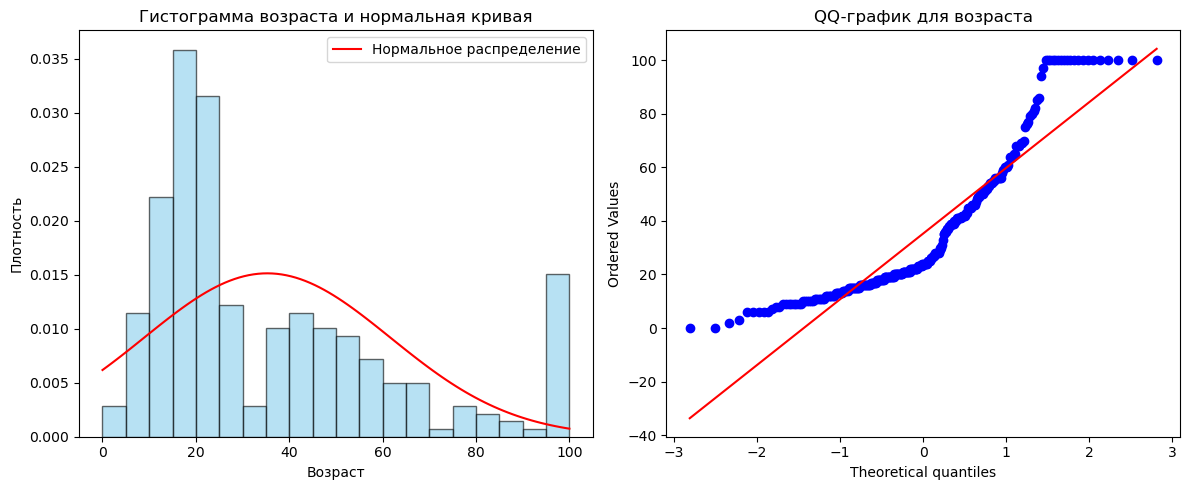

In [15]:
age_clean = data['age'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Гистограмма с наложенной кривой нормального распределения
axes[0].hist(age_clean, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')
x = np.linspace(age_clean.min(), age_clean.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, age_clean.mean(), age_clean.std()), 'r-', label='Нормальное распределение')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Гистограмма возраста и нормальная кривая')
axes[0].legend()

# QQ-график
stats.probplot(age_clean, dist="norm", plot=axes[1])
axes[1].set_title('QQ-график для возраста')

plt.tight_layout()
plt.show()

## 6. Визуализация с помощью Plotly

### 6.1 Несколько графиков разного вида

In [16]:
fig1 = px.histogram(data, x='age', nbins=20, title='Распределение возраста (Plotly)')
fig1.show()

In [17]:
alive_counts = data.groupby(['male', 'isAlive']).size().reset_index(name='count')
alive_counts['gender'] = alive_counts['male'].map({0:'Женщины',1:'Мужчины'})
alive_counts['alive'] = alive_counts['isAlive'].map({0:'Мёртв',1:'Жив'})
fig2 = px.bar(alive_counts, x='gender', y='count', color='alive', barmode='group',
              title='Количество персонажей по полу и выживаемости')
fig2.show()

In [18]:
fig3 = px.scatter(data, x='age', y='popularity', color='male',
                  title='Популярность vs Возраст (Plotly)',
                  labels={'male':'Пол', 'age':'Возраст', 'popularity':'Популярность'})
fig3.show()

### 6.2 Суб-графики в Plotly

In [19]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Распределение возраста', 'Возраст по полу'))

# Гистограмма
fig.add_trace(go.Histogram(x=data['age'].dropna(), nbinsx=20, name='Возраст'), row=1, col=1)

# Boxplot для мужчин и женщин
fig.add_trace(go.Box(y=data[data['male']==1]['age'].dropna(), name='Мужчины'), row=1, col=2)
fig.add_trace(go.Box(y=data[data['male']==0]['age'].dropna(), name='Женщины'), row=1, col=2)

fig.update_layout(title_text='Субграфики Plotly', showlegend=False)
fig.show()

### 6.3 Интерактивный график с дополнительными элементами

In [20]:
fig = px.scatter_matrix(data, dimensions=['age','popularity','numDeadRelations'],
                        color='isAlive', title='Матрица рассеяния (интерактив)')
fig.update_traces(diagonal_visible=False)
fig.show()